In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler

tmin = -.5
tmax=2.0
fmin=0.5
fmax = 16
sfreq = 32

paradigm = MotorImagery(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax,  n_classes=7)
dataset= Weibo2014()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         #subjects=[2],
                                         return_epochs=True)
"""
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]
"""

Choosing from all possible events


Using default location ~/mne_data for Weibo 2014...


Trial data de-meaned and concatenated with a buffer to create cont data


Using default location ~/mne_data for Weibo 2014...


Trial data de-meaned and concatenated with a buffer to create cont data


...

Trial data de-meaned and concatenated with a buffer to create cont data


Using default location ~/mne_data for Weibo 2014...


Trial data de-meaned and concatenated with a buffer to create cont data


Not setting metadata
560 matching events found
No baseline correction applied
Not setting metadata
560 matching events found
No baseline correction applied
Not setting metadata
560 matching events found
No baseline correction applied
Not setting metadata
560 matching events found
No baseline correction applied
Not setting metadata
560 matching events found
No baseline correction applied
Not setting metadata
500 matching events found
No baseline correction applied
Not setting metadata
560 matching events found
No baseline correction applied
Not setting metadata
560 matching events found
No baseline correction applied
Not setting metadata
560 matching events found
No baseline correction applied
Not setting metadata
560 matching events found
No baseline correction applied
Not setting metadata
5540 matching events found
No baseline correction applied


"\nsession = meta['session'][0]\nidc = meta['session'] == session\nepochs = epochs[idc]\nlabels = labels[idc]\nmeta = meta[idc]\n"

In [3]:
epochs

Number of events,5540
Events,feet: 790hands: 790left_hand: 790left_hand_right_foot: 790rest: 800right_hand: 790right_hand_left_foot: 790
Time range,2.500 – 4.969 s
Baseline,off


In [4]:
meta

,subject,session,run
0,1,session_0,run_0
1,1,session_0,run_0
2,1,session_0,run_0
3,1,session_0,run_0
4,1,session_0,run_0
...,...,...,...
5535,10,session_0,run_0
5536,10,session_0,run_0
5537,10,session_0,run_0
5538,10,session_0,run_0


No projector specified for this dataset. Please consider the method self.add_proj.


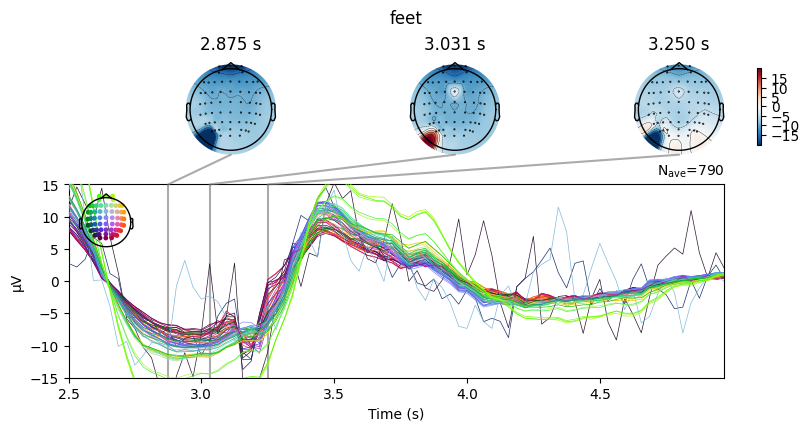

No projector specified for this dataset. Please consider the method self.add_proj.


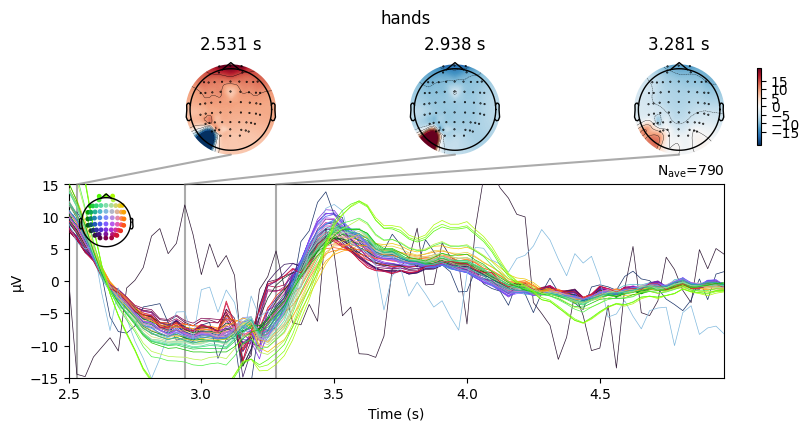

No projector specified for this dataset. Please consider the method self.add_proj.


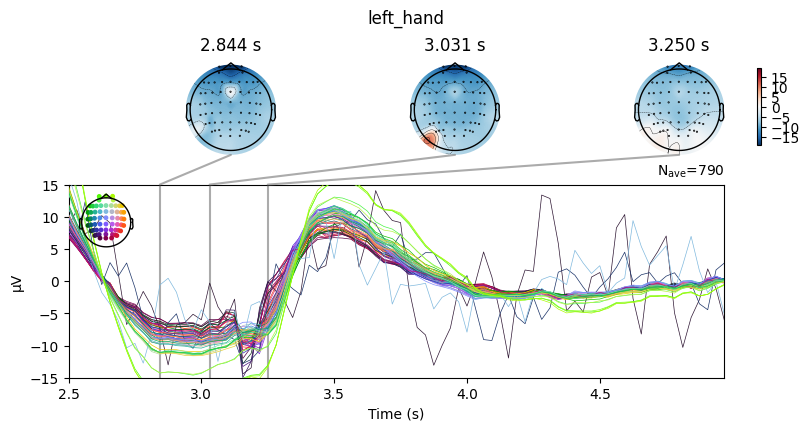

No projector specified for this dataset. Please consider the method self.add_proj.


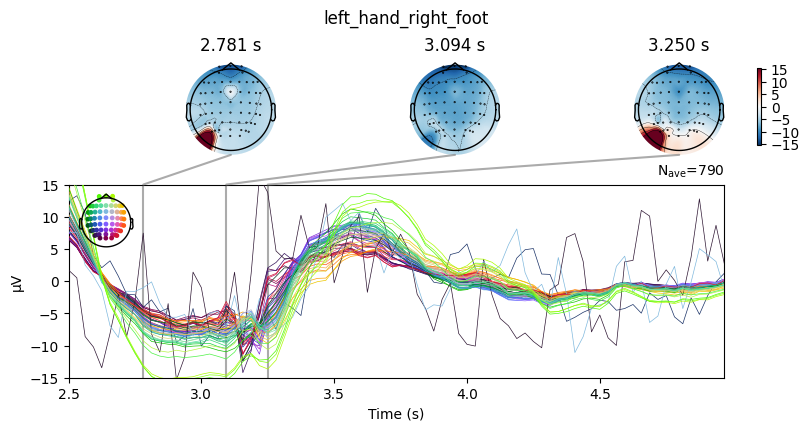

No projector specified for this dataset. Please consider the method self.add_proj.


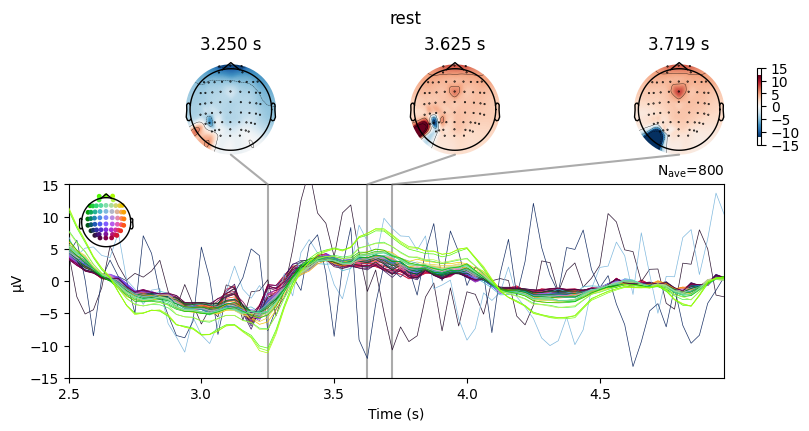

No projector specified for this dataset. Please consider the method self.add_proj.


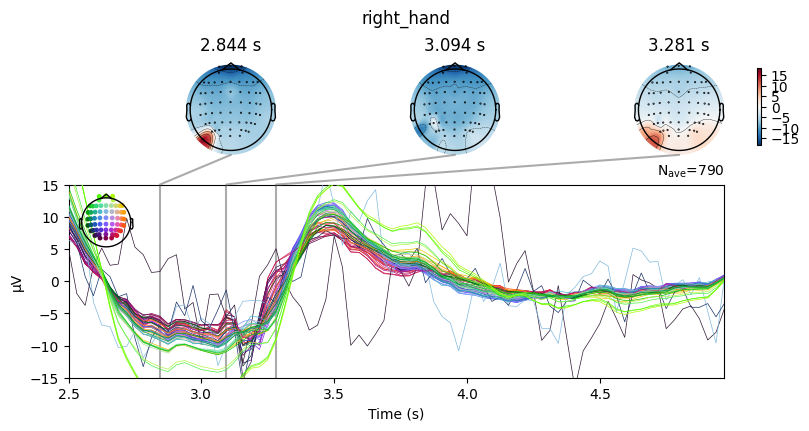

No projector specified for this dataset. Please consider the method self.add_proj.


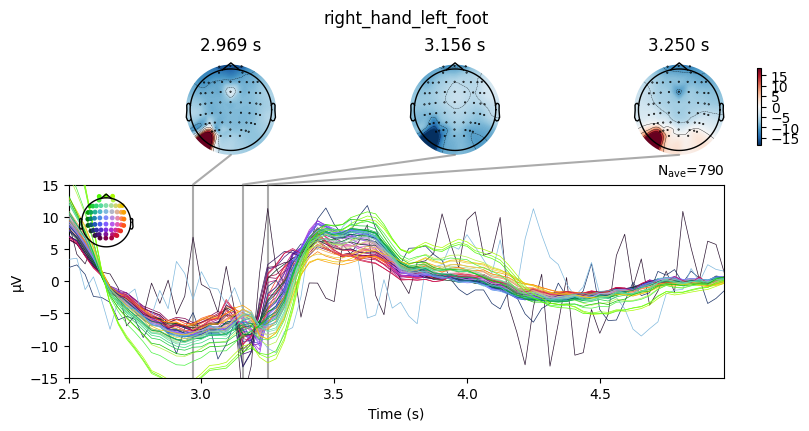

In [5]:
import numpy as np
ts_args=dict(ylim=dict(eeg=[-15,15]))
joint_args=dict(ts_args=ts_args)
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

In [6]:
X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_326/2444922706.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(5540, 60, 80)

In [7]:
from hoda.hoda import aHODA, f_multiway
from hoda.gpu_opt import center
import warnings

from hoda.hoda import f_oneway, mode_scatter
from hoda.gpu_opt import center, ledoit_wolf_shrinkage, combine_pvalues

hoda = aHODA(
            rank=None,
            max_iter=256,
            tol=1e-8,
            init ='mlsvd',
            shrinkage='lw',
            toeplitz=None,
            taper=False,
            obj='rt',
            solver='lanczos',
            keep_train_info=False,
            verbose=True,
        )
hoda.fit(X,y)

Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (1, 1) ...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (2, 2) ...
Initializing factors...
Fitting discriminative Tucker model...


...

  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (17, 17) ...
Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (16, 16) ...


aHODA()

In [8]:
hoda.train_info_

,update
iteration,
0.0,2.861185e-02
1.0,2.908474e-02
2.0,2.773415e-02
3.0,2.666240e-02
4.0,2.648428e-02
5.0,2.412078e-02
6.0,2.369544e-02
7.0,1.824504e-02
8.0,1.273196e-02


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

if hoda.keep_train_info:
    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.train_info_, x='iteration', y='F', ax=axs[0])
    axs[1].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_, x='iteration', y='p', ax=axs[1])
    axs[1].set(yscale='log')
    sns.lineplot(data=hoda.train_info_, x='iteration', y='mse', ax=axs[2])
    axs[2].set(yscale="log")
    axs[2].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_, x='iteration', y='update', ax=axs[3])
    axs[3].set(yscale="log")


    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='objective',hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='rank',hue='mode', ax=axs[1])
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='update',hue='mode', ax=axs[2])
    axs[2].set(yscale="log")
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='shrinkage',hue='mode', ax=axs[3])

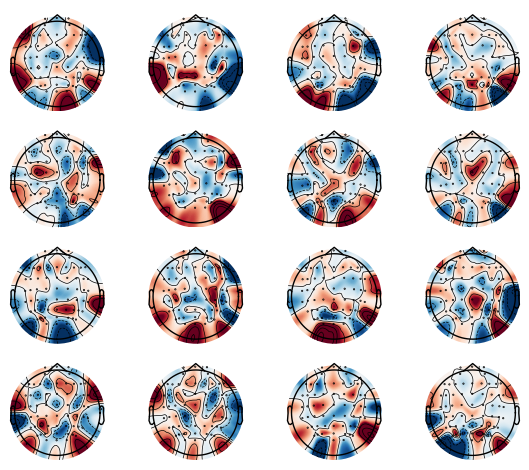

In [10]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl


col_wrap = 4

if len(epochs.ch_names)>1:
    n_col = col_wrap
    n_row = int( np.ceil(hoda.rank_(0) / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col, layout='tight')
    for i in range(hoda.rank_(0)):
        w = tl.to_numpy(hoda.scalings_[0][:,i])
        plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)


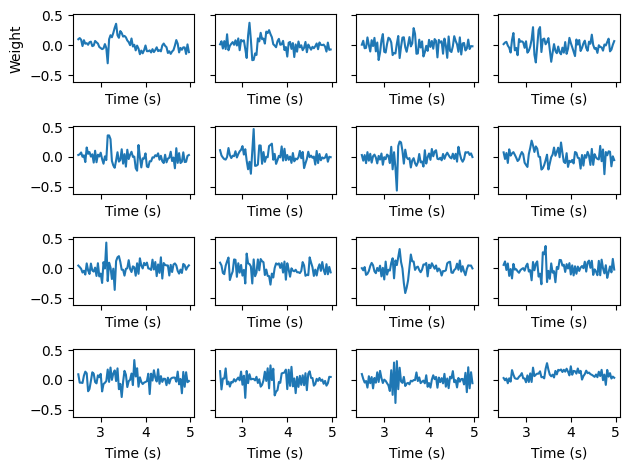

In [11]:
n_row = int( np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_(1)):
    w = tl.to_numpy(hoda.scalings_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


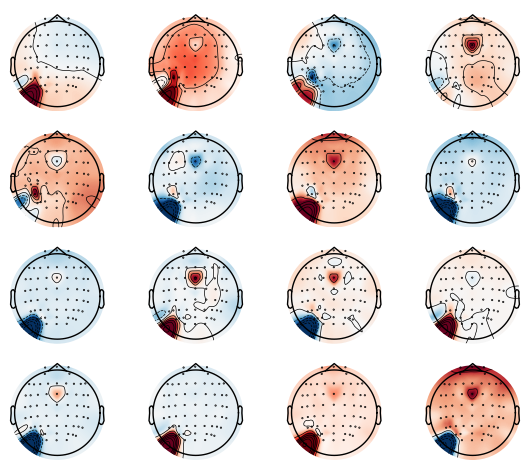

In [12]:
if len(epochs.ch_names)>1:

    n_row = int(np.ceil(hoda.rank_(0) / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col, layout='tight')
    A = hoda.aps_[0]
    for i in range(hoda.rank_(0)):
        a = tl.to_numpy(A[:,i])
        plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)



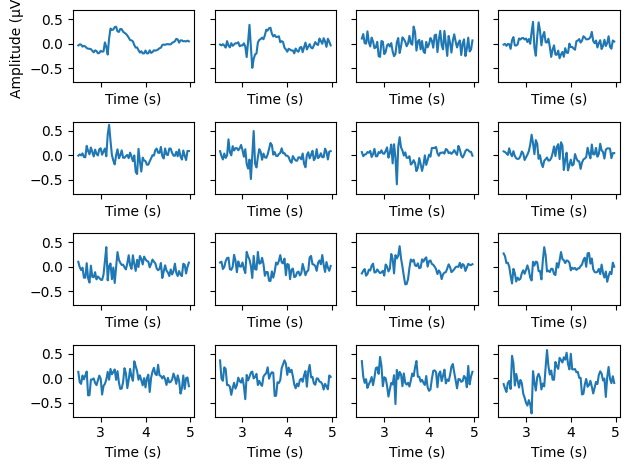

In [13]:

n_row = int(np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_(1)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude (µV)');

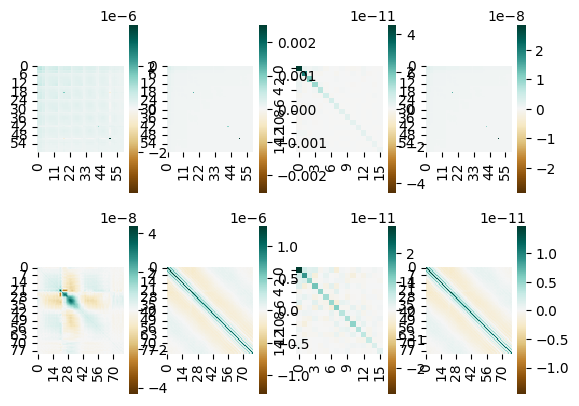

In [14]:
_, axs = plt.subplots(2,4,)
for k in range(2):
    
    scatter_b = tl.to_numpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[k,0].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    
    
    scatter_w = tl.to_numpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    
    axs[k,1].set_aspect('equal')


    cov_l= tl.to_numpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    
    axs[k,2].set_aspect('equal')


    cov =  tl.to_numpy(hoda.cov_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    
    axs[k,3].set_aspect('equal')

In [15]:
Xt = hoda.transform(X)

In [16]:
X.shape

(5540, 60, 80)

[0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 1.25824560e-109 5.01876918e-108 1.63262504e-069 1.43398354e-143
 5.78575644e-120 6.09943989e-085 2.02054815e-077 2.90018761e-061
 1.50212982e-060 4.20330529e-058 9.51012379e-051 2.20364725e-066]
[0.00000000e+000 0.00000000e+000 7.25474273e-091 3.60471246e-170
 3.08202029e-200 1.00781978e-203 3.70013063e-218 1.89248428e-185
 4.33448163e-112 1.17057018e-093 6.35692200e-186 2.08881720e-080
 7.24947185e-105 5.91036777e-030 3.70587039e-040 4.47842413e-042]


<BarContainer object of 16 artists>

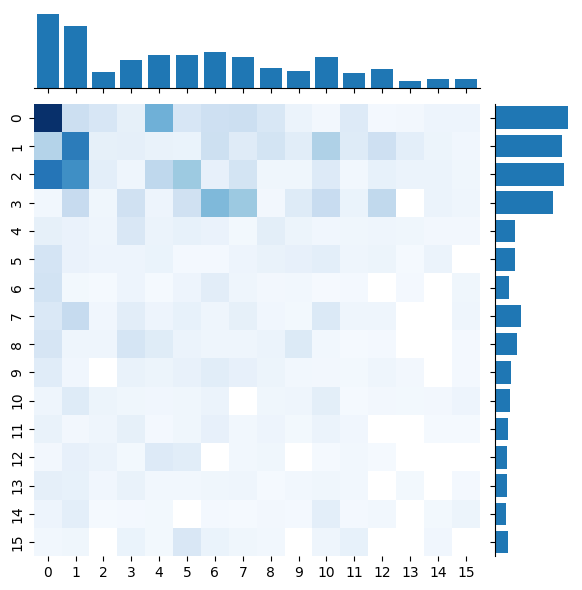

In [17]:
from hoda.hoda import f_multiway
from hoda.gpu_opt import combine_pvalues

snr,p = f_multiway(X,y)
F, p = f_oneway(Xt,y)


Xsq_sp, p_sp = combine_pvalues(p, axis=(1,))
Xsq_tmp, p_tmp = combine_pvalues(p, axis=(0,))
print(p_sp)
print(p_tmp)

Xsq_sp = tl.to_numpy(Xsq_sp)
Xsq_tmp = tl.to_numpy(Xsq_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)

g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.05,cbar=False, cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, Xsq_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, Xsq_sp)

<Axes: xlabel='0', ylabel='1'>

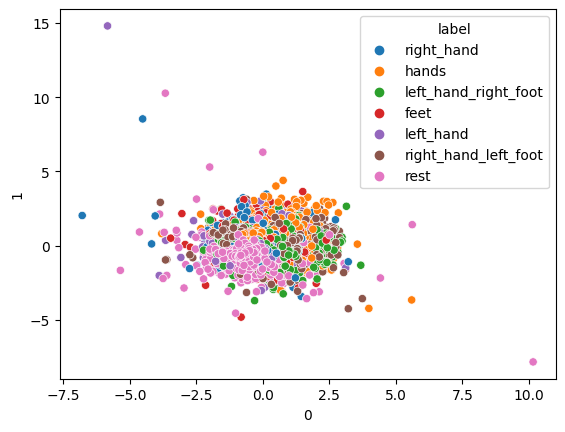

In [18]:
import pandas as pd
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

X_viz = X.reshape((X.shape[0],-1))
Xt_viz = Xt.reshape((Xt.shape[0],-1))
n_components = 2
decomp  = PCA(n_components=n_components, whiten=True)
X_viz = decomp.fit_transform(tl.to_numpy(X_viz))
Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_viz))

df = pd.DataFrame(Xt_viz)
df['label'] = labels
sns.scatterplot(data=df, x=0, y=1, hue='label')

No projector specified for this dataset. Please consider the method self.add_proj.


/tmp/ipykernel_326/3696127509.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))


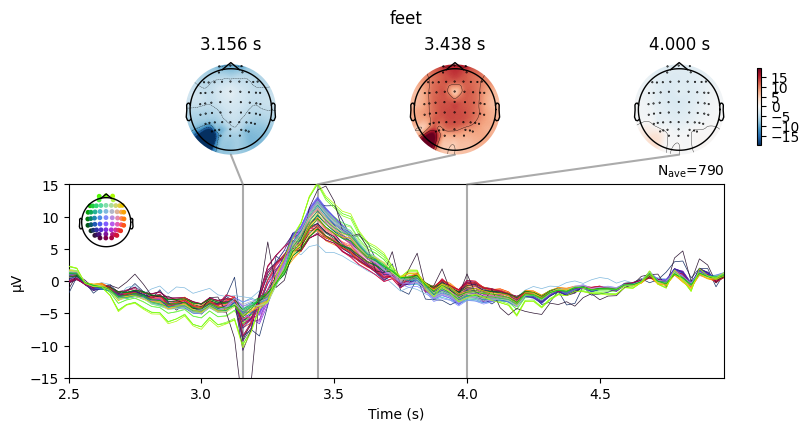

No projector specified for this dataset. Please consider the method self.add_proj.


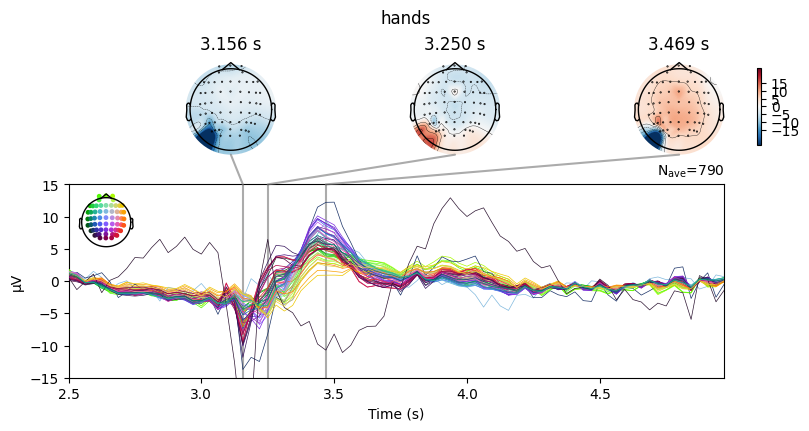

No projector specified for this dataset. Please consider the method self.add_proj.


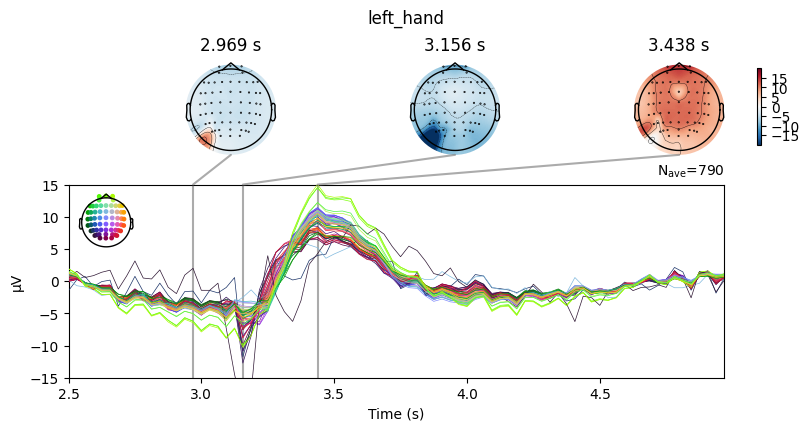

No projector specified for this dataset. Please consider the method self.add_proj.


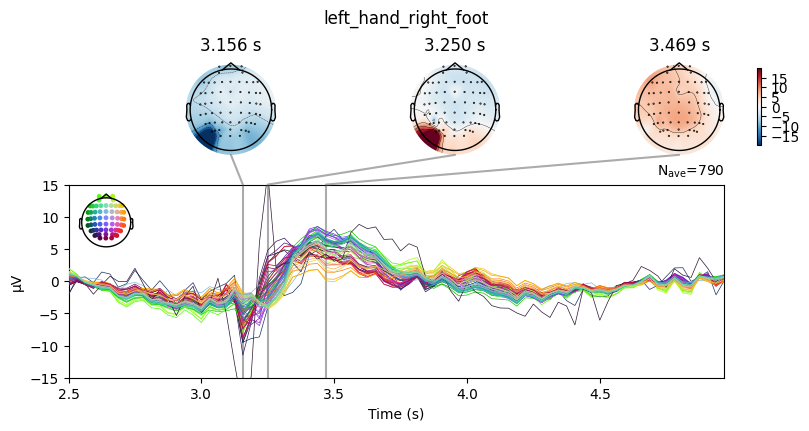

No projector specified for this dataset. Please consider the method self.add_proj.


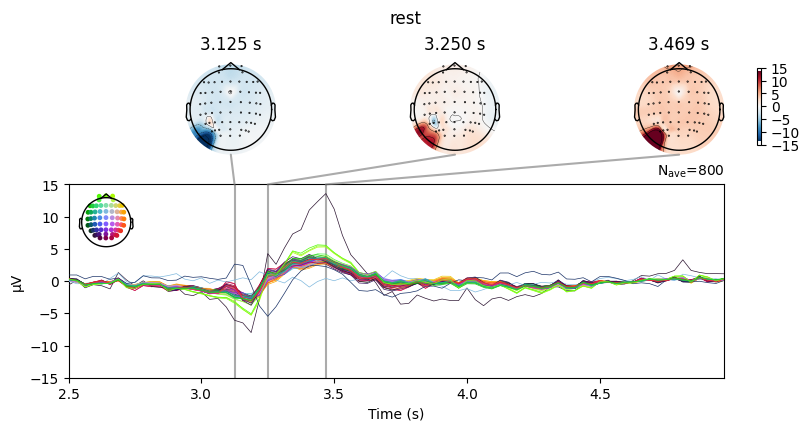

No projector specified for this dataset. Please consider the method self.add_proj.


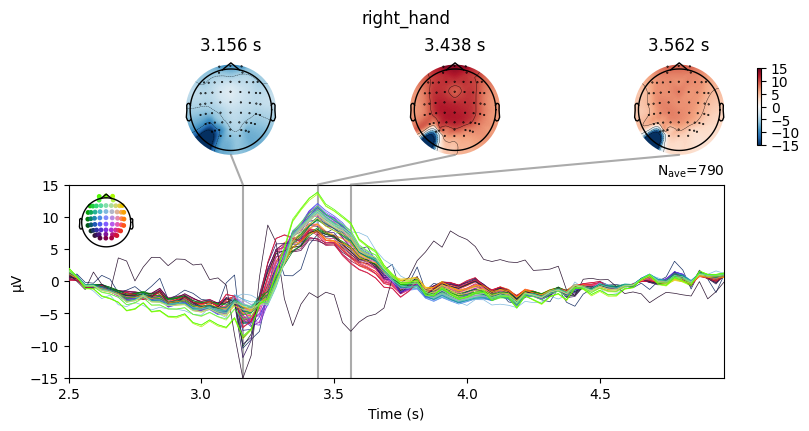

No projector specified for this dataset. Please consider the method self.add_proj.


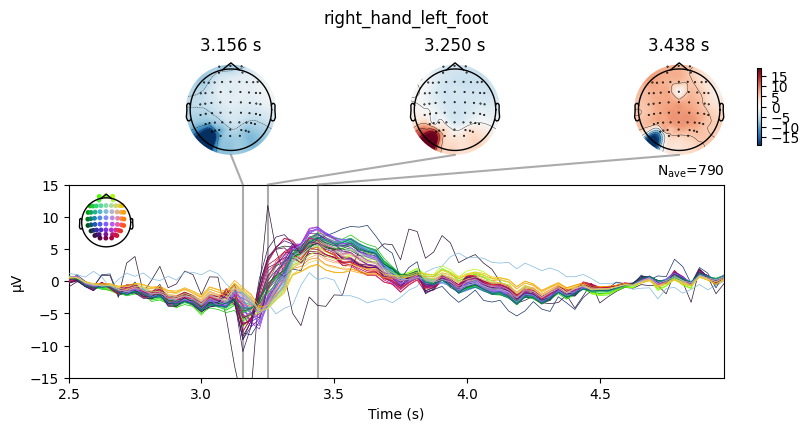

In [19]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))

for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.plot_joint(title=cls, **joint_args)
    else:
        evoked_rec.plot(**ts_args)